finetune_class
5_sunflower                86
1_wheat                    57
0_maize                    25
3_rapeseed                 15
4_soybean                  12
9_orchard                  10
7_other_temporary_crops    10
8_vineyard                  6
6_sugarbeet                 5
2_barley                    4
Name: count, dtype: int64


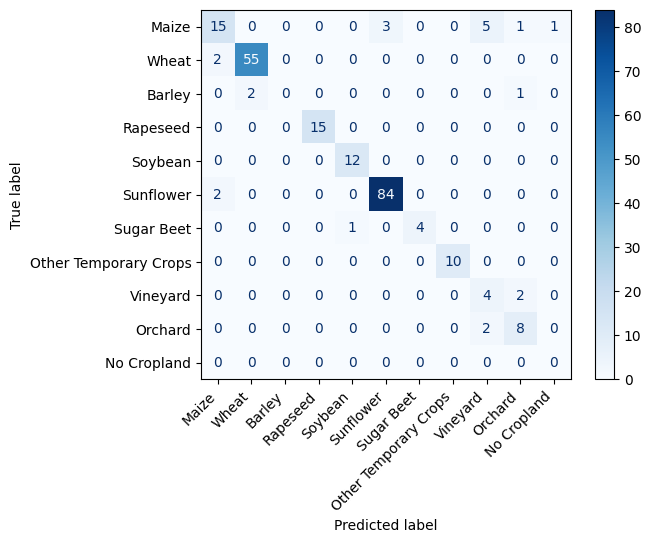

In [5]:
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Read the GeoParquet file
gdf = pd.read_csv("/vitodata/worldcereal/data/COP4GEOGLAM/moldova/results/sampled_test/MDA_test_points_sampled_v1401.csv")

print(gdf["finetune_class"].value_counts())

true_label_mapping = {
    "0_maize": "Maize",
    "1_wheat": "Wheat",
    "2_barley": "Barley",
    "3_rapeseed": "Rapeseed",
    "4_soybean": "Soybean",
    "5_sunflower": "Sunflower",
    "6_sugarbeet": "Sugar Beet",
    "7_other_temporary_crops": "Other Temporary Crops",
    "8_vineyard": "Vineyard",
    "9_orchard": "Orchard"
}

pred_label_mapping = {
    0: "Maize",
    1: "Wheat",
    2: "Barley",
    3: "Rapeseed",
    4: "Soybean",
    5: "Sunflower",
    6: "Sugar Beet",
    7: "Other Temporary Crops",
    8: "Vineyard",
    9: "Orchard",
    254: "No Cropland"
}

#remove the false point of finetune_class: barley and v21: rapeseed
gdf = gdf[~((gdf["finetune_class"] == "2_barley") & (gdf["v21"] == 3))]



# Map both true and predicted labels to string class names
y_true = gdf["finetune_class"].map(true_label_mapping)
y_pred = gdf["v21"].map(pred_label_mapping)

# Remove rows with unmapped or missing values
mask = y_true.notna() & y_pred.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# Define the set of labels to use in the confusion matrix
labels = [
    "Maize", "Wheat", "Barley", "Rapeseed", "Soybean", "Sunflower",
    "Sugar Beet", "Other Temporary Crops", "Vineyard", "Orchard", "No Cropland"
]

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=labels)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

# Rotate x-axis labels
plt.setp(plt.gca().get_xticklabels(), rotation=45, ha="right")

plt.show()